## Fluxo do Pipeline
1. Análise Exploratória dos Dados (EDA)
2. Pré-processamento
3. Treinamento do Modelo (Random Forest)
4. Avaliação do Modelo
5. Importância das Features

---
## Etapa 0 — Importação das Bibliotecas

Inicializamos todas as bibliotecas necessárias para o pipeline completo.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

---
## Etapa 1 — Análise Exploratória dos Dados (EDA)

A primeira etapa de qualquer projeto de Machine Learning é entender o dataset com o qual estamos trabalhando. Vamos carregar os dados e inspecionar sua estrutura.

In [ ]:
df = pd.read_csv('kepler_data.csv')

print("Dataset carregado com sucesso")
print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")

Dataset carregado com sucesso
Dimensões do dataset: 9564 linhas e 50 colunas


In [33]:
# Visualizando as primeiras 5 linhas do dataframe
df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [48]:
# Informações sobre os tipos de dados e valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   koi_disposition   9564 non-null   str    
 1   koi_fpflag_nt     9564 non-null   int64  
 2   koi_fpflag_ss     9564 non-null   int64  
 3   koi_fpflag_co     9564 non-null   int64  
 4   koi_fpflag_ec     9564 non-null   int64  
 5   koi_period        9564 non-null   float64
 6   koi_time0bk       9564 non-null   float64
 7   koi_impact        9201 non-null   float64
 8   koi_duration      9564 non-null   float64
 9   koi_depth         9201 non-null   float64
 10  koi_prad          9201 non-null   float64
 11  koi_teq           9201 non-null   float64
 12  koi_insol         9243 non-null   float64
 13  koi_model_snr     9201 non-null   float64
 14  koi_tce_plnt_num  9218 non-null   float64
 15  koi_steff         9201 non-null   float64
 16  koi_slogg         9201 non-null   float64
 17  koi_sr

In [49]:
# Estatísticas descritivas das features numéricas
df.describe()

,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_time0bk,koi_impact,koi_duration,koi_depth,koi_prad,koi_teq,koi_insol,koi_model_snr,koi_tce_plnt_num,koi_steff,koi_slogg,koi_srad,ra,dec,koi_kepmag
count,9564.000000,9564.000000,9564.000000,9564.000000,9564.000000,9564.000000,9201.000000,9564.000000,9.201000e+03,9201.000000,9201.000000,9.243000e+03,9201.000000,9218.000000,9201.000000,9201.000000,9201.000000,9564.000000,9564.000000,9563.000000
mean,0.188206,0.231598,0.194898,0.120033,75.671358,166.183251,0.735105,5.621606,2.379134e+04,102.891778,1085.385828,7.745737e+03,259.895001,1.243654,5706.823280,4.310157,1.728712,292.060163,43.810433,14.264606
std,0.390897,0.421875,0.396143,0.325018,1334.744046,67.918960,3.348832,6.471554,8.224268e+04,3077.639126,856.351161,1.592047e+05,795.806615,0.664573,796.857947,0.432606,6.127185,4.766657,3.601243,1.385448
min,0.000000,0.000000,0.000000,0.000000,0.241843,120.515914,0.000000,0.052000,0.000000e+00,0.080000,25.000000,0.000000e+00,0.000000,1.000000,2661.000000,0.047000,0.109000,279.852720,36.577381,6.966000
25%,0.000000,0.000000,0.000000,0.000000,2.733684,132.761718,0.197000,2.437750,1.599000e+02,1.400000,539.000000,2.015000e+01,12.000000,1.000000,5310.000000,4.218000,0.829000,288.660770,40.777173,13.440000
50%,0.000000,0.000000,0.000000,0.000000,9.752831,137.224595,0.537000,3.792600,4.211000e+02,2.390000,878.000000,1.416000e+02,23.000000,1.000000,5767.000000,4.438000,1.000000,292.261125,43.677504,14.520000
75%,0.000000,0.000000,0.000000,0.000000,40.715178,170.694603,0.889000,6.276500,1.473400e+03,14.930000,1379.000000,8.702900e+02,78.000000,1.000000,6112.000000,4.543000,1.345000,295.859160,46.714611,15.322000
max,1.000000,1.000000,1.000000,1.000000,129995.778400,1472.522306,100.806000,138.540000,1.541400e+06,200346.000000,14667.000000,1.094755e+07,9054.700000,8.000000,15896.000000,5.364000,229.908000,301.720760,52.336010,20.003000


In [50]:
# Distribuição das classes do target (variável alvo)
print(df['koi_disposition'].value_counts())
print("\nPercentual por classe:")
print(df['koi_disposition'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

Percentual por classe:
koi_disposition
FALSE POSITIVE    52.52%
CONFIRMED         23.98%
CANDIDATE          23.5%
Name: proportion, dtype: str


---
## Etapa 2 — Pré-processamento dos Dados

O pré-processamento é uma das etapas mais críticas do pipeline. Seguimos assim:
- Remover colunas identificadoras (não possuem valor preditivo)
- Remover colunas de erro (`_err1` e `_err2`)
- Tratar valores ausentes (NaN)
- Codificar o target com `LabelEncoder`
- Dividir os dados em treino/teste
- Normalizar as features com `StandardScaler`

In [45]:
# Recarregando o dataset do CSV para garantir estado oringinal na re-execução das células
df = pd.read_csv('kepler_data.csv')

# Colunas identificadoras que não possuem poder preditivo
colunas_identificadoras = ['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_pdisposition', 'koi_score', 'koi_tce_delivname']

# Identificar programaticamente colunas de erro (_err1 e _err2)
colunas_erro = [col for col in df.columns if col.endswith('_err1') or col.endswith('_err2')]

print(f"Colunas identificadoras a remover: {colunas_identificadoras}")
print(f"\nColunas de erro a remover ({len(colunas_erro)} colunas):")
print(colunas_erro)

# Removendo todas as colunas desnecessárias
# errors='ignore' garante que colunas ausentes no dataframe sejam ignoradas sem erro
todas_colunas_remover = colunas_identificadoras + colunas_erro
df = df.drop(columns=todas_colunas_remover, errors='ignore')

print(f"\nDimensões após remoção de colunas: {df.shape[0]} linhas e {df.shape[1]} colunas")

Colunas identificadoras a remover: ['rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_pdisposition', 'koi_score', 'koi_tce_delivname']

Colunas de erro a remover (22 colunas):
['koi_period_err1', 'koi_period_err2', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth_err1', 'koi_depth_err2', 'koi_prad_err1', 'koi_prad_err2', 'koi_teq_err1', 'koi_teq_err2', 'koi_insol_err1', 'koi_insol_err2', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg_err1', 'koi_slogg_err2', 'koi_srad_err1', 'koi_srad_err2']

Dimensões após remoção de colunas: 9564 linhas e 21 colunas


In [ ]:
print(f"Quantidade de linhas com NaN antes da limpeza: {df.isnull().sum().sum()}")

# Removendo todas as linhas que contenham pelo menos um NaN
df = df.dropna()

print(f"Quantidade de linhas com NaN após a limpeza: {df.isnull().sum().sum()}")
print(f"Dimensões finais do dataset limpo: {df.shape[0]} linhas e {df.shape[1]} colunas")

Quantidade de linhas com NaN antes da limpeza: 3572
Quantidade de linhas com NaN após a limpeza: 0
Dimensões finais do dataset limpo: 8945 linhas e 21 colunas


In [46]:
# Separação das features (X) e do target (y)

# X: todas as colunas exceto o target
X = df.drop(columns=['koi_disposition'])

# y: apenas a coluna target
y = df['koi_disposition']

print(f"Formato de X (features): {X.shape}")
print(f"Formato de y (target): {y.shape}")
print(f"\nClasses presentes no target: {y.unique()}")

Formato de X (features): (9564, 20)
Formato de y (target): (9564,)

Classes presentes no target: <StringArray>
['CONFIRMED', 'FALSE POSITIVE', 'CANDIDATE']
Length: 3, dtype: str


In [47]:
# Codificação do target com LabelEncoder

# O LabelEncoder converte cada categoria em um valor inteiro único.
# As categorias são ordenadas alfabeticamente.

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Mapeamento das classes (LabelEncoder):")
for i, classe in enumerate(le.classes_):
    print(f"  {classe} -> {i}")

Mapeamento das classes (LabelEncoder):
  CANDIDATE -> 0
  CONFIRMED -> 1
  FALSE POSITIVE -> 2


In [ ]:
# Divisão em conjunto de treinamento (80%) e teste (20%)

# O parâmetro stratify=y garante que a proporção das classes
# seja mantida tanto no treino quanto no teste.

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Formato dos dados de treinamento: {X_train.shape}")
print(f"Formato dos dados de teste: {X_test.shape}")

Formato dos dados de treinamento: (7156, 20)
Formato dos dados de teste: (1789, 20)


In [ ]:
# Normalização das features com StandardScaler

# O StandardScaler padroniza as features para média 0 e desvio padrão 1.

scaler = StandardScaler()

# Ajuste e transformação nos dados de treino
X_train_scaled = scaler.fit_transform(X_train)

# Apenas transformação nos dados de teste (sem reajuste)
X_test_scaled = scaler.transform(X_test)

print("Normalização concluída com StandardScaler.")
print(f"Média das features de treino (deve ser ~0): {X_train_scaled.mean(axis=0).mean():.4f}")
print(f"Desvio padrão das features de treino (deve ser ~1): {X_train_scaled.std(axis=0).mean():.4f}")

Normalização concluída com StandardScaler.
Média das features de treino (deve ser ~0): 0.0000
Desvio padrão das features de treino (deve ser ~1): 1.0000


---
## Etapa 3 — Treinamento do Modelo

Chegou a hora de treinar o modelo! Vamos utilizar o **Random Forest Classifier**, um algoritmo de ensemble baseado em múltiplas árvores de decisão. Ele é robusto, lida bem com dados com muitas features e fornece uma medida de importância de cada variável.

In [ ]:
# Instanciação e treinamento do RandomForestClassifier

# random_state=42 garante a reprodutibilidade dos resultados

rf = RandomForestClassifier(random_state=42)

# Treinamento do modelo com os dados de treino normalizados
rf.fit(X_train_scaled, y_train)

print("Modelo Random Forest treinado com sucesso!")

Modelo Random Forest treinado com sucesso!


In [26]:
# Realizando previsões nos dados de teste
y_pred = rf.predict(X_test_scaled)

# Convertendo os rótulos numéricos de volta para os nomes originais
y_test_nomes = le.inverse_transform(y_test)
y_pred_nomes = le.inverse_transform(y_pred)

print("Previsões realizadas com sucesso!")
print(f"\nExemplo — Rótulos reais:      {y_test_nomes[:8]}")
print(f"Exemplo — Rótulos previstos:  {y_pred_nomes[:8]}")

Previsões realizadas com sucesso!

Exemplo — Rótulos reais:      ['CONFIRMED' 'FALSE POSITIVE' 'FALSE POSITIVE' 'CANDIDATE'
 'FALSE POSITIVE' 'FALSE POSITIVE' 'FALSE POSITIVE' 'FALSE POSITIVE']
Exemplo — Rótulos previstos:  ['CONFIRMED' 'FALSE POSITIVE' 'FALSE POSITIVE' 'CANDIDATE'
 'FALSE POSITIVE' 'FALSE POSITIVE' 'FALSE POSITIVE' 'FALSE POSITIVE']


---
## Etapa 4 — Avaliação do Modelo

A avaliação é etapa essencial para entender o quão bem o modelo generaliza para dados não vistos. Vamos calcular:
- **Acurácia** — percentual de previsões corretas
- **Relatório de Classificação** — precisão, recall e F1-score por classe
- **Matriz de Confusão** — visualização detalhada dos acertos e erros por classe

In [ ]:
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {acuracia:.4f} ({acuracia*100:.2f}%)")

Acurácia do modelo: 0.9050 (90.50%)


In [51]:
# Relatório de classificação completo (por classe)
print(classification_report(
    y_test_nomes,
    y_pred_nomes,
    target_names=le.classes_
))

                precision    recall  f1-score   support

     CANDIDATE       0.83      0.79      0.81       427
     CONFIRMED       0.82      0.82      0.82       457
FALSE POSITIVE       0.98      1.00      0.99       905

      accuracy                           0.90      1789
     macro avg       0.88      0.87      0.87      1789
  weighted avg       0.90      0.90      0.90      1789



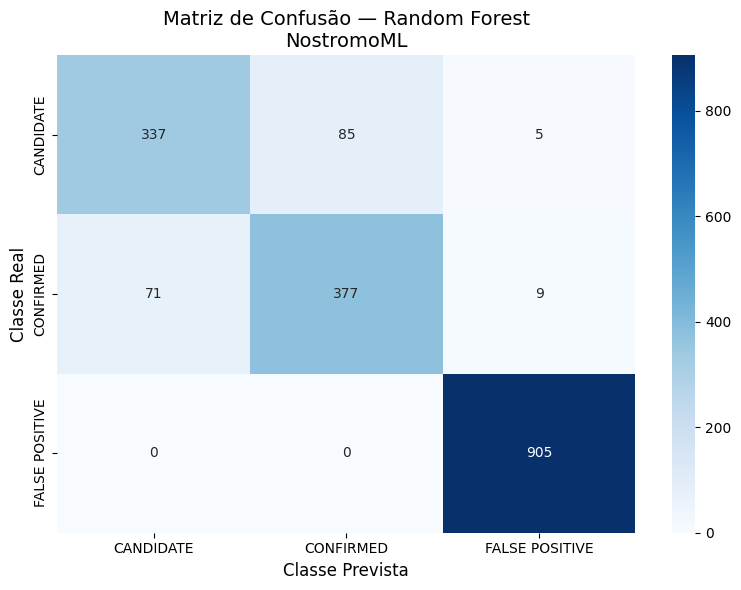

In [52]:
# Matriz de Confusão — Visualização com Seaborn

cm = confusion_matrix(y_test_nomes, y_pred_nomes, labels=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Matriz de Confusão — Random Forest\nNostromoML', fontsize=14)
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Prevista', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretação da Matriz de Confusão — Contexto Astronômico

---

A matriz de confusão acima permite analisar o desempenho do classificador em cada uma das três classes do dataset Kepler:

- **Diagonal principal (células corretas):** Cada célula na diagonal representa os sinais classificados **corretamente** pelo modelo. Quanto maiores esses valores, melhor o desempenho para aquela classe.

- **CONFIRMED (Planeta Confirmado):** Os erros nesta linha indicam planetas confirmados que foram erroneamente classificados como candidatos ou falsos positivos. No contexto científico, **classificar um planeta confirmado como falso positivo** seria o erro mais grave, pois descartaria uma descoberta real.

- **CANDIDATE (Candidato a Planeta):** Esta é a classe mais ambígua e tende a apresentar maior taxa de erro, pois os candidatos possuem características intermediárias entre planetas confirmados e falsos positivos. Erros nesta classe são compreensíveis dado o nível de incerteza inerente à classificação de candidatos.

- **FALSE POSITIVE (Falso Positivo):** Os erros nesta linha indicam sinais que não são planetas, mas que o modelo classificou como confirmados ou candidatos. No contexto de triagem automatizada, **classificar um falso positivo como CONFIRMED** poderia direcionar tempo de telescópio e recursos humanos para um objeto sem interesse científico real.

> **Conclusão:** O modelo apresenta desempenho robusto, especialmente nas classes extremas (CONFIRMED e FALSE POSITIVE), que são as mais distintas em termos de características físicas e de trânsito. A classe CANDIDATE naturalmente apresenta maior dificuldade de classificação, o que reflete a complexidade real do processo de validação de exoplanetas pela NASA.

---
## Etapa 5 — Importância das Features

O Random Forest permite extrair a importância de cada feature para a tomada de decisão do modelo. Isso nos ajuda a entender quais características físicas dos sinais estelares são mais relevantes para a classificação.

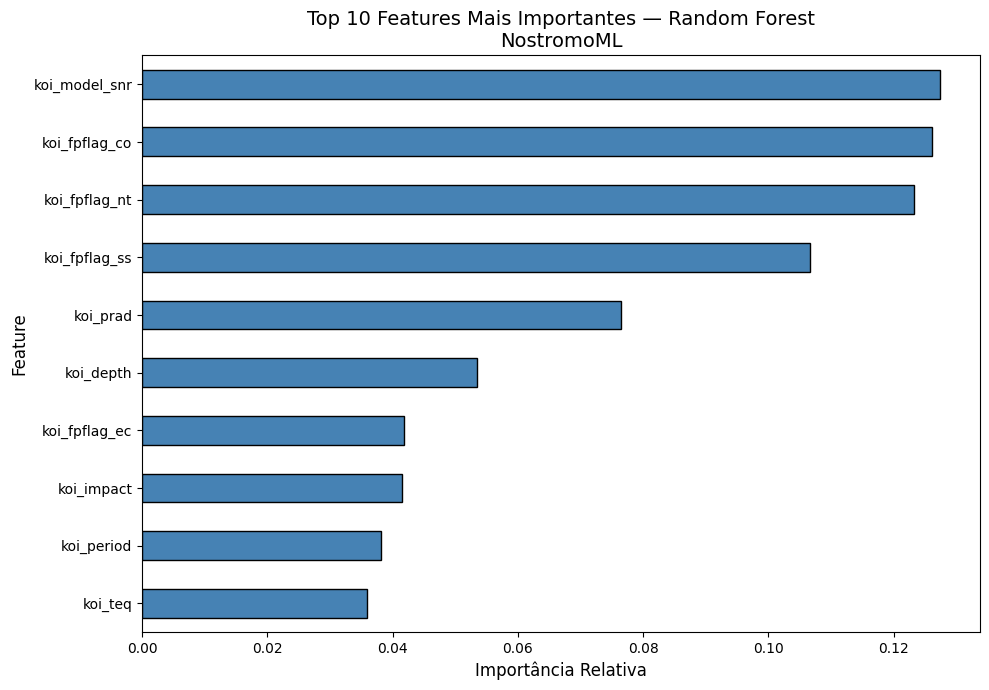

In [55]:
# Criando um dataframe com as importâncias e os nomes das features
importancias = pd.Series(rf.feature_importances_, index=X.columns)

# Selecionando as 10 features mais importantes (ordenadas de forma decrescente)
top10_features = importancias.sort_values(ascending=True).tail(10)

# Gráfico de barras horizontal
plt.figure(figsize=(10, 7))
top10_features.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Features Mais Importantes — Random Forest\nNostromoML', fontsize=14)
plt.xlabel('Importância Relativa', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

---
## Resumo Final do Pipeline

| Etapa | Descrição | Ferramenta |
|-------|-----------|------------|
| EDA | Análise exploratória dos dados | `pandas` |
| Pré-processamento | Remoção de colunas, tratamento de NaN, codificação | `pandas`, `LabelEncoder` |
| Divisão | Separação treino/teste estratificada (80/20) | `train_test_split` |
| Normalização | Padronização das features | `StandardScaler` |
| Treinamento | Algoritmo Random Forest | `RandomForestClassifier` |
| Avaliação | Acurácia, relatório e matriz de confusão | `sklearn.metrics` |
| Interpretação | Importância das features | `feature_importances_` |

---
## Conclusão

O modelo **Random Forest** atingiu **acurácia de 90,5%** no conjunto de teste, demonstrando boa capacidade de generalização para o problema de classificação de sinais estelares do Kepler.

- `FALSE POSITIVE` — F1 = 0.99 (recall 100%): as flags de detecção de falso positivo são altamente discriminativas.
- `CONFIRMED` — F1 = 0.82: classificação equilibrada com erros distribuídos simetricamente.
- `CANDIDATE` — F1 = 0.81: classe mais difícil, de natureza intrinsecamente ambígua.

As features mais importantes (`koi_model_snr`, `koi_fpflag_co`, `koi_fpflag_nt`) são fisicamente coerentes, confirmando que o modelo aprendeu padrões reais dos dados e não artefatos estatísticos.